In [1]:
import pickle
from collections import Counter

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

from utils.experiment import load_config
from utils.streaming.factories import create_transformer
from utils.streaming.inference import infer_trace

In [34]:
experiment_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/BPIC_20_DD/aht_8f294d20_2026-03-11_11-16-39'

results_path = f'{experiment_path}/results.csv'

model_path = f'{experiment_path}/model.pkl'

config_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/conf/experiments/streaming/aht/BPIC_20_DD_no_drift.yaml'

dataset_path = 'C:/Users/Pavel/Desktop/PROJECTS/master-thesis/datasets/stream/synthetic/no_drift.xes'

## Load Results and Model

In [35]:
# load config
config = load_config(config_path)

# load model
with open(model_path, 'rb') as f:
    model = pickle.load(f)

# load results from csv
results_df = pd.read_csv(results_path)

print(f'Results rows: {len(results_df)}')
print(f'Model type: {type(model).__name__}')
print('Model params:')
for k, v in model._get_params().items():
    print(f'  {k:<30}: {v}')

Results rows: 56437
Model type: HoeffdingAdaptiveTreeClassifier
Model params:
  grace_period                  : 100
  max_depth                     : 20
  split_criterion               : info_gain
  delta                         : 0.001
  tau                           : 0.05
  leaf_prediction               : nba
  nb_threshold                  : 10
  nominal_attributes            : None
  splitter                      : (<class 'river.tree.splitter.gaussian_splitter.GaussianSplitter'>, {'n_splits': 10})
  bootstrap_sampling            : True
  drift_window_threshold        : 300
  drift_detector                : (<class 'utils.streaming.drift_detector.NoDriftDetector'>, {})
  switch_significance           : 0.05
  binary_split                  : False
  min_branch_fraction           : 0.01
  max_share_to_split            : 0.99
  max_size                      : 100.0
  memory_estimate_period        : 1000000
  stop_mem_management           : False
  remove_poor_attrs             : Fals

## Adaptive Hoeffding Tree (AHT)

### Tree Structure

#### Helper functions

In [11]:
def build_dot(node, dot=None, parent_id=None, edge_label='', node_counter=None):
    if dot is None:
        dot = graphviz.Digraph(graph_attr={'rankdir': 'TB'})
        node_counter = [0]

    if node is None:
        return dot

    node_id = str(node_counter[0])
    node_counter[0] += 1

    feature = getattr(node, 'feature', None)
    children_raw = getattr(node, 'children', {})

    # normalise to dict {label: child_node}
    if isinstance(children_raw, dict):
        children = children_raw
    elif isinstance(children_raw, list):
        children = {str(i): child for i, child in enumerate(children_raw)}
    else:
        children = {}

    if feature is not None:
        # Branch node
        label = f'split: {feature}'
        dot.node(node_id, label=label, shape='box', style='filled', fillcolor='#AED6F1')
    else:
        # Leaf node — 'stats' is the correct attribute (not '_stats')
        stats = getattr(node, 'stats', {})
        if stats:
            total = sum(stats.values())
            sorted_classes = sorted(stats.items(), key=lambda x: x[1], reverse=True)
            lines = [f'total: {total:.0f}'] + [
                f'{cls}: {cnt:.0f}' for cls, cnt in sorted_classes[:5]
            ]
            if len(sorted_classes) > 5:
                lines.append(f'... +{len(sorted_classes) - 5} more')
            label = '\n'.join(lines)
        else:
            label = 'leaf\n(empty)'
        dot.node(
            node_id, label=label, shape='ellipse', style='filled', fillcolor='#A9DFBF'
        )

    if parent_id is not None:
        dot.edge(parent_id, node_id, label=str(edge_label))

    for child_key, child in children.items():
        build_dot(
            child,
            dot,
            parent_id=node_id,
            edge_label=child_key,
            node_counter=node_counter,
        )

    return dot


def collect_split_features(node, counter=None):
    if counter is None:
        counter = Counter()
    if node is None:
        return counter

    feature = getattr(node, 'feature', None)
    if feature is not None:
        counter[feature] += 1

    children_raw = getattr(node, 'children', {})
    if isinstance(children_raw, dict):
        children = list(children_raw.values())
    elif isinstance(children_raw, list):
        children = children_raw
    else:
        children = []

    for child in children:
        collect_split_features(child, counter)

    return counter

#### Analysis

In [12]:
summary = model.summary
print('Tree structure summary:')
for k, v in summary.items():
    print(f'{k:<25}: {v}')

print(f'\nMemory usage: {model._raw_memory_usage:,} bytes')

Tree structure summary:
n_nodes                  : 12
n_branches               : 2
n_leaves                 : 10
n_active_leaves          : 130
n_inactive_leaves        : 0
height                   : 3
total_observed_weight    : 45937.0
n_alternate_trees        : 8
n_pruned_alternate_trees : 0
n_switch_alternate_trees : 0

Memory usage: 10,643,832 bytes


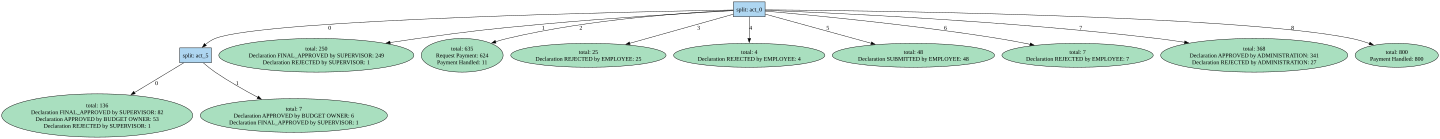

In [13]:
dot = build_dot(model._root)
dot.attr(size='20,20')
display(dot)

Distinct features used in splits: 2


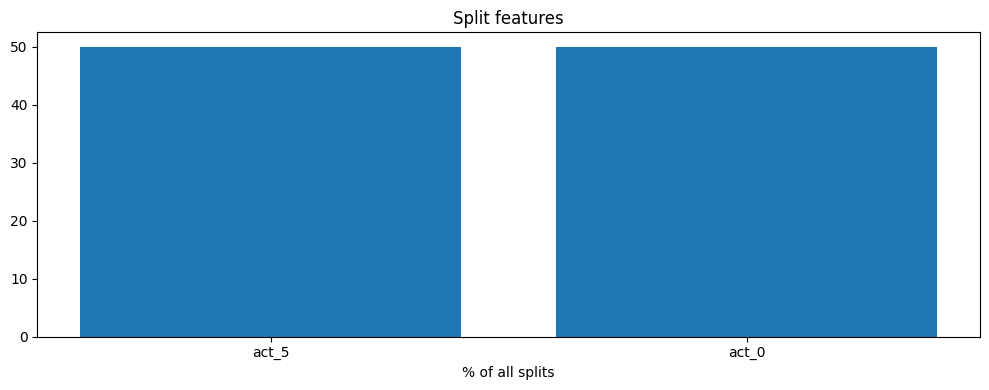

In [14]:
split_counts = collect_split_features(model._root)
fi_df = (
    pd.DataFrame(split_counts.items(), columns=['feature', 'split_count'])
    .sort_values('split_count', ascending=False)
    .reset_index(drop=True)
)
fi_df['split_pct'] = fi_df['split_count'] / fi_df['split_count'].sum() * 100

print(f'Distinct features used in splits: {len(fi_df)}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fi_df['feature'][::-1], fi_df['split_pct'][::-1])
ax.set_xlabel('% of all splits')
ax.set_title('Split features')
plt.tight_layout()
plt.show()

In [15]:
drift_det = getattr(model, 'drift_detector', None)

print(f'Number of drifts detected: {getattr(drift_det, "n_detections", "n/a")}')

Number of drifts detected: 0


#### Test predictions

In [16]:
trace_id = None
seed = 123

transformer = create_transformer(config['transformer'])

trace_df, trace_id = infer_trace(
    model=model,
    transformer=transformer,
    dataset_path=dataset_path,
    trace_id=trace_id,
    seed=seed,
)

print(f'Trace ID: {trace_id}')
print(f'Length: {len(trace_df)} events')
print(f'Accuracy: {trace_df["correct"].dropna().mean():.2%}\n')

display(trace_df)

Trace ID: declaration 88175
Length: 4 events
Accuracy: 66.67%



,step,prefix_len,y_true,y_pred,y_pred_prob,correct
0,0,0,Declaration SUBMITTED by EMPLOYEE,None,NaN,None
1,1,1,Declaration FINAL_APPROVED by SUPERVISOR,Declaration APPROVED by ADMINISTRATION,0.926630,False
2,2,2,Request Payment,Request Payment,0.995006,True
3,3,3,Payment Handled,Payment Handled,1.000000,True


## Training curves

In [82]:
def safe_f1(df, y_true_col='y_true', y_pred_col='y_pred'):
    return f1_score(df[y_true_col], df[y_pred_col], average='macro', zero_division=0)

In [ ]:
def plot_stream_metric(
    results_df: pd.DataFrame,
    metric: str = 'macro_f1',
    window: int = 100,
    center_window: bool = False,
    figsize: tuple[int, int] = (12, 4),
    save_path: str | None = None,
    actual_drift_points: list[int] | None = None,
) -> plt.Axes:
    """
    Plot a prequential metric over stream progress with concept drift markers.
    """
    stream_df = (
        results_df.sort_values('trace_n')
        .dropna(subset=['y_pred'])
        .reset_index(drop=True)
        .copy()
    )
    roll_kw = {'window': window, 'center': center_window, 'min_periods': 1}

    if metric == 'accuracy':
        correct = (stream_df['y_true'] == stream_df['y_pred']).astype(float)

        metric_values = correct.rolling(**roll_kw).mean()

        ylabel = 'Accuracy'
        line_label = f'Accuracy (window={window}, center={center_window})'

    elif metric == 'macro_f1':
        unique_classes = np.union1d(
            stream_df['y_true'].unique(), stream_df['y_pred'].unique()
        )

        tp_cols, fp_cols, fn_cols = [], [], []
        for c in unique_classes:
            is_true_c = stream_df['y_true'] == c
            is_pred_c = stream_df['y_pred'] == c

            tp_cols.append((is_true_c & is_pred_c).astype(float))
            fp_cols.append((~is_true_c & is_pred_c).astype(float))
            fn_cols.append((is_true_c & ~is_pred_c).astype(float))

        tp_roll = pd.concat(tp_cols, axis=1).rolling(**roll_kw).sum().values
        fp_roll = pd.concat(fp_cols, axis=1).rolling(**roll_kw).sum().values
        fn_roll = pd.concat(fn_cols, axis=1).rolling(**roll_kw).sum().values

        nom = 2 * tp_roll
        denom = 2 * tp_roll + fp_roll + fn_roll

        f1_per_class = np.full_like(denom, np.nan)
        np.divide(nom, denom, out=f1_per_class, where=denom > 0)

        # Macro average: only over classes *present* in each window (denom > 0)
        with np.errstate(all='ignore'):
            metric_values = pd.Series(
                np.nanmean(f1_per_class, axis=1), index=stream_df.index
            )

        ylabel = 'Macro F1-score'
        line_label = f'Macro F1 (window={window}, center={center_window})'

    else:
        raise ValueError(f'Unknown {metric}')

    # Rows where the drift counter first increments
    detected_drift_points = (
        results_df[results_df['n_drifts'].diff() > 0]
        .drop_duplicates('n_drifts')['trace_n']
        .values
    )

    _, ax = plt.subplots(figsize=figsize)

    ax.plot(
        stream_df['trace_n'],
        metric_values,
        linewidth=1.5,
        color='steelblue',
        label=line_label,
    )
    for i, dt in enumerate(detected_drift_points):
        ax.axvline(
            dt,
            color='red',
            linewidth=0.8,
            linestyle='--',
            alpha=0.7,
            label='Detected drift' if i == 0 else None,
        )

    if actual_drift_points:
        for i, dt in enumerate(actual_drift_points):
            ax.axvline(
                dt,
                color='green',
                linewidth=1.2,
                linestyle='-',
                alpha=0.8,
                label='Actual drift' if i == 0 else None,
            )

    ax.set_xlabel('Stream Progress (Trace #)')
    ax.set_ylabel(ylabel)
    ax.set_title(line_label)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

    return ax

<Axes: title={'center': 'Accuracy (window=100, center=True)'}, xlabel='Stream Progress (Trace #)', ylabel='Accuracy'>

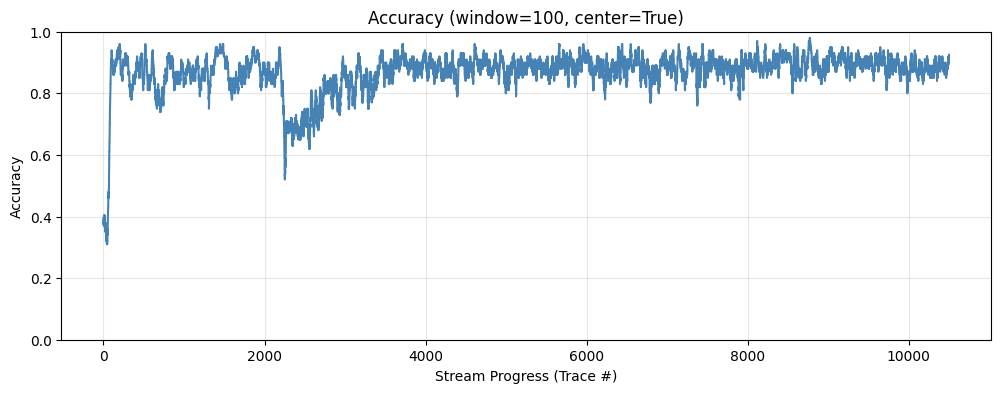

In [57]:
plot_stream_metric(
    results_df,
    metric='accuracy',
    window=100,
    center_window=True,
    figsize=(12, 4),
)

### F-score vs Prefix Length

Is my model better at predicting the outcome at the start of the trace or near the end?

C:\Users\Pavel\AppData\Local\Temp\ipykernel_16464\2068106296.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_f1)


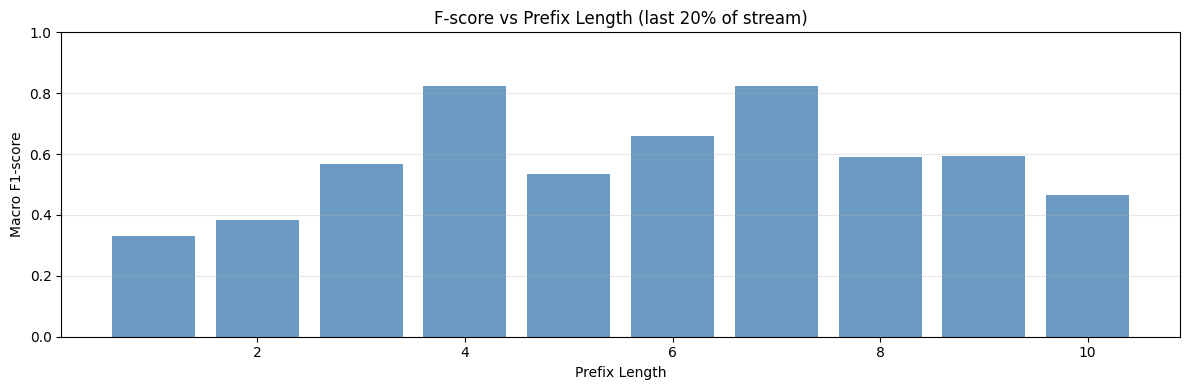

In [38]:
MIN_NUM_OF_TRACES = 10
RECENT_FRACTION = 0.2  # only the last % of the stream

valid = results_df.dropna(subset=['y_pred']).copy()

trace_n_threshold = valid['trace_n'].quantile(1 - RECENT_FRACTION)
recent_valid = valid[valid['trace_n'] >= trace_n_threshold]

counts_per_prefix = recent_valid.groupby('prefix_len').size()
reliable_prefixes = counts_per_prefix[counts_per_prefix >= MIN_NUM_OF_TRACES].index

f1_prefix = (
    recent_valid[recent_valid['prefix_len'].isin(reliable_prefixes)]
    .groupby('prefix_len')
    .apply(safe_f1)
    .reset_index(name='macro_f1')
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    f1_prefix['prefix_len'],
    f1_prefix['macro_f1'],
    width=0.8,
    alpha=0.8,
    color='steelblue',
)
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Macro F1-score')
ax.set_title(f'F-score vs Prefix Length (last {RECENT_FRACTION:.0%} of stream)')
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### F-score vs Stream Progress

Is the model learning over time?

1000


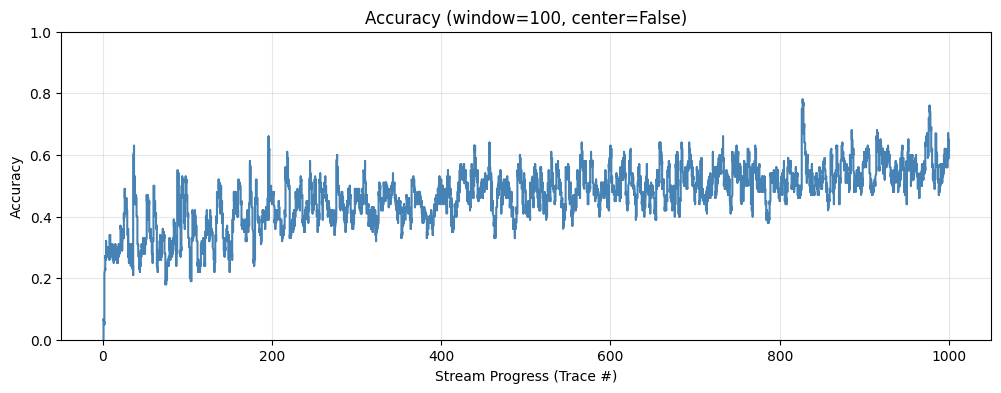

In [99]:
plot_stream_metric(
    results_df,
    metric='accuracy',
    window=100,
    center_window=False,
    save_path='accuracy_over_time.png',
)

### Prediction Density

C:\Users\Pavel\AppData\Local\Temp\ipykernel_16464\1141550279.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(safe_f1)


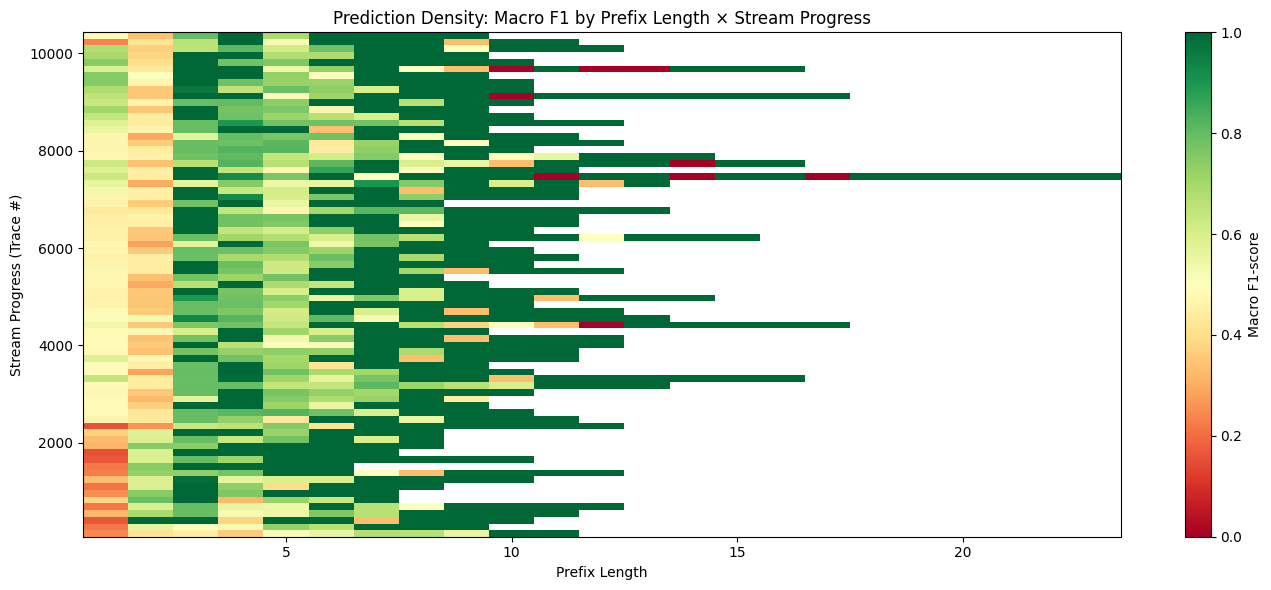

In [41]:
N_TRACE_BINS = 75

valid = results_df.dropna(subset=['y_pred']).copy()

valid['trace_bin'] = pd.cut(valid['trace_n'], bins=N_TRACE_BINS, labels=False)

# Compute macro F1 per (prefix_len, trace_bin)
cell_f1 = (
    valid.groupby(['prefix_len', 'trace_bin'])
    .apply(safe_f1)
    .reset_index(name='macro_f1')
)

# Pivot to 2D matrix
f1_pivot = cell_f1.pivot(index='trace_bin', columns='prefix_len', values='macro_f1')

prefix_labels = f1_pivot.columns.tolist()
trace_bin_edges = np.linspace(
    valid['trace_n'].min(), valid['trace_n'].max(), N_TRACE_BINS + 1
)
trace_centers = (trace_bin_edges[:-1] + trace_bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(
    f1_pivot.values,
    origin='lower',
    aspect='auto',
    extent=[
        min(prefix_labels) - 0.5,
        max(prefix_labels) + 0.5,
        trace_centers[0],
        trace_centers[-1],
    ],
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
)
plt.colorbar(im, ax=ax, label='Macro F1-score')
ax.set_xlabel('Prefix Length')
ax.set_ylabel('Stream Progress (Trace #)')
ax.set_title('Prediction Density: Macro F1 by Prefix Length × Stream Progress')
plt.tight_layout()
plt.show()


In [38]:
results_df.tail(40)

results_df['n_pred'].nunique()

len(results_df[~results_df['y_pred'].isnull()])

45931

## Comparison table

In [1]:
import pandas as pd
from river import metrics as river_metrics

from pathlib import Path

In [2]:
METRIC_FACTORIES = {
    'macro_f1': river_metrics.MacroF1,
    'accuracy': river_metrics.Accuracy,
}


def recompute_running_metrics(
    predictions_df: pd.DataFrame, start_event_num: int = 0
) -> pd.DataFrame:
    """Recompute running metrics from a given event onwards."""
    metrics_dict = {name: factory() for name, factory in METRIC_FACTORIES.items()}

    predictions_df = (
        predictions_df[predictions_df['event_n'] >= start_event_num]
        .sort_values('event_n')
        .reset_index(drop=True)
        .copy()
    )

    running_values = {name: [] for name in metrics_dict}

    for _, row in predictions_df.iterrows():
        y_true = row['y_true']
        y_pred = row['y_pred']

        if pd.notna(y_true) and pd.notna(y_pred):
            for metric in metrics_dict.values():
                metric.update(y_true, y_pred)

        for metric_name, metric in metrics_dict.items():
            running_values[metric_name].append(f'{metric.get():.3f}')

    for metric_name, values in running_values.items():
        predictions_df[metric_name] = values

    return predictions_df


def first_prediction_event_n(predictions_df: pd.DataFrame) -> float:
    """Return first event_n where model outputs a prediction."""
    pred_mask = pd.notna(predictions_df['y_pred'])

    if 'n_pred' in predictions_df.columns:
        pred_mask &= predictions_df['n_pred'] >= 1

    first_event = predictions_df.loc[pred_mask, 'event_n'].min()
    return first_event

In [7]:
BASE_FOLDER = Path('C:/Users/Pavel/Desktop/PROJECTS/master-thesis/experiments/outputs/streaming/next_activity/baseline/')

BASE_FILENAME = 'results.csv'

predictions_dict = {
    'BPIC_13_C': {
        'darwin': 'bpic_13_c_darwin_classifier_211d8663_2026-04-15_22-52-27',
        # 'darwin_transformer': '',
        'aht': 'bpic_13_c_aht_c1652eae_2026-04-15_22-44-19',
        'arf': 'bpic_13_c_arf_ac2b77f3_2026-04-15_22-45-26',
        'srp': 'bpic_13_c_srp_f890cc58_2026-04-15_23-04-22',
    },
    'BPIC_13_I': {
        'darwin': 'bpic_13_i_darwin_classifier_f5457a3f_2026-04-15_22-52-51',
        # 'darwin_transformer': '',
        'aht': 'bpic_13_i_aht_9b6579da_2026-04-15_22-44-19',
        'arf': 'bpic_13_i_arf_e709e107_2026-04-15_22-45-34',
        'srp': 'bpic_13_i_srp_31aecc01_2026-04-15_23-07-51',
    },
    'BPIC_20_DD': {
        'darwin': 'bpic_20_dd_darwin_classifier_3c0299d4_2026-04-18_17-21-20',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_dd_aht_c24b3254_2026-04-15_22-44-19',
        'arf': 'bpic_20_dd_arf_c23a081c_2026-04-15_22-45-48',
        'srp': 'bpic_20_dd_srp_bf20df3d_2026-04-15_23-09-29',
    },
    'BPIC_20_ID': {
        'darwin': 'bpic_20_id_darwin_classifier_4b5024e5_2026-04-15_22-57-19',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_id_aht_6fe17736_2026-04-15_22-44-19',
        'arf': 'bpic_20_id_arf_f314de13_2026-04-15_22-47-48',
        'srp': 'bpic_20_id_srp_8d4dfdea_2026-04-15_23-14-49',
    },
    'BPIC_20_PTC': {
        'darwin': 'bpic_20_ptc_darwin_classifier_729cf2bb_2026-04-16_10-09-48',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_ptc_aht_4662ecef_2026-04-15_22-44-27',
        'arf': 'bpic_20_ptc_arf_e4bebb94_2026-04-15_22-48-10',
        'srp': 'bpic_20_ptc_srp_772e4d4b_2026-04-15_23-17-16',
    },
    'BPIC_20_RFP': {
        'darwin': 'bpic_20_rfp_darwin_classifier_8f2b2fc2_2026-04-16_11-10-14',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_rfp_aht_a4ff834c_2026-04-15_22-45-08',
        'arf': 'bpic_20_rfp_arf_976c404e_2026-04-15_22-49-37',
        'srp': 'bpic_20_rfp_srp_6d6af37b_2026-04-15_23-37-07',
    },
    'BPIC_20_TPD': {
        'darwin': 'bpic_20_tpd_darwin_classifier_57466802_2026-04-15_23-00-40',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_tpd_aht_0a206627_2026-04-15_22-45-12',
        'arf': 'bpic_20_tpd_arf_5d26b40a_2026-04-15_22-51-11',
        'srp': 'bpic_20_tpd_srp_a96ff756_2026-04-16_07-56-14',
    },
    'Helpdesk': {
        'darwin': 'bpic_20_tpd_darwin_classifier_57466802_2026-04-15_23-00-40',
        # 'darwin_transformer': '',
        'aht': 'bpic_20_tpd_aht_0a206627_2026-04-15_22-45-12',
        'arf': 'bpic_20_tpd_arf_5d26b40a_2026-04-15_22-51-11',
        'srp': 'bpic_20_tpd_srp_a96ff756_2026-04-16_07-56-14',
    },
}

In [8]:
summary_rows = []

for dataset_name, predictions_path_dict in predictions_dict.items():
    # start_event_num = maximum first-prediction event across ALL models in this dataset
    first_pred_events = {}
    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        first_pred_events[model_name] = first_prediction_event_n(df)

    start_event_num = int(max(first_pred_events.values()))

    row = {'dataset_name': dataset_name}

    print(f'Dataset: {dataset_name}, start_event_num: {start_event_num}')

    for model_name, folder_path in predictions_path_dict.items():
        path = BASE_FOLDER / folder_path / BASE_FILENAME
        df = pd.read_csv(path)
        recomputed_df = recompute_running_metrics(df, start_event_num=start_event_num)

        last_row = recomputed_df.iloc[-1]

        for metric in METRIC_FACTORIES.keys():
            row[(metric, model_name)] = last_row[metric]

    summary_rows.append(row)

comparison_table_df = pd.DataFrame(summary_rows).set_index('dataset_name').sort_index()


Dataset: BPIC_13_C, start_event_num: 966
Dataset: BPIC_13_I, start_event_num: 7337
Dataset: BPIC_20_DD, start_event_num: 7335
Dataset: BPIC_20_ID, start_event_num: 8390
Dataset: BPIC_20_PTC, start_event_num: 2130
Dataset: BPIC_20_RFP, start_event_num: 4762
Dataset: BPIC_20_TPD, start_event_num: 10064
Dataset: Helpdesk, start_event_num: 10064


In [9]:
model_order = ['darwin', 'darwin_transformer', 'aht', 'arf', 'srp']
metric_order = ['macro_f1', 'accuracy']

if not comparison_table_df.empty:
    ordered_cols = [
        (metric, model_name)
        for metric in metric_order
        for model_name in model_order
        if (metric, model_name) in comparison_table_df.columns
    ]

    comparison_table_df = comparison_table_df[ordered_cols]
    comparison_table_df.columns = pd.MultiIndex.from_tuples(
        comparison_table_df.columns, names=['metric', 'model']
    )

comparison_table_df

metric       macro_f1                      accuracy                     
model          darwin    aht    arf    srp   darwin    aht    arf    srp
dataset_name                                                            
BPIC_13_C       0.488  0.402  0.454  0.455    0.540  0.566  0.622  0.613
BPIC_13_I       0.518  0.270  0.326  0.318    0.675  0.634  0.637  0.640
BPIC_20_DD      0.421  0.443  0.391  0.461    0.877  0.865  0.890  0.886
BPIC_20_ID      0.475  0.396  0.417  0.414    0.798  0.793  0.823  0.814
BPIC_20_PTC     0.420  0.449  0.494  0.459    0.804  0.818  0.847  0.831
BPIC_20_RFP     0.383  0.384  0.370  0.407    0.860  0.870  0.877  0.867
BPIC_20_TPD     0.358  0.349  0.262  0.240    0.754  0.769  0.624  0.606
Helpdesk        0.358  0.349  0.262  0.240    0.754  0.769  0.624  0.606